# Experiment 1 & 2: Image Classification

**Dog Breed Classification — Stanford Dogs (10 Breeds)**

- **Exp 1**: Baseline ResNet18 pretrained on ImageNet, fine-tuned for 10 dog breeds
- **Exp 2**: Modified ResNet18 — `layer4` removed, reducing feature dimension 512 → 256

Both experiments share the same train/val/test split (70/15/15), optimizer, scheduler,
and early stopping criteria. Pretrained ImageNet weights are reused for all layers
present in both architectures; only the classifier head in Exp 2 is randomly initialised.

**Student ID**: 26045171

In [1]:
import random
from collections import defaultdict
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, resnet18

In [2]:
STUDENT_ID = 26045171
torch.manual_seed(STUDENT_ID)
random.seed(STUDENT_ID)
np.random.seed(STUDENT_ID)
if torch.cuda.is_available():
    torch.cuda.manual_seed(STUDENT_ID)

DATASET_ROOT  = Path("26045171/Image_Classification/dataset")
EXP1_DIR      = Path("runs/exp1_resnet18")
EXP2_DIR      = Path("runs/exp2_resnet18_shallow")
EXP1_DIR.mkdir(parents=True, exist_ok=True)
EXP2_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES   = 10
BATCH_SIZE    = 256
EPOCHS        = 150
PATIENCE      = 30
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
# ImageFolder with no transform returns raw PIL Images, which lets us apply
# different transforms to each split without duplicating the dataset on disk.
base_dataset = ImageFolder(DATASET_ROOT)
CLASS_NAMES  = base_dataset.classes
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Total images: {len(base_dataset)}")

def stratified_split(dataset, train_ratio=0.70, val_ratio=0.15, seed=STUDENT_ID):
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.imgs):
        class_indices[label].append(idx)
    rng = random.Random(seed)
    train_idx, val_idx, test_idx = [], [], []
    for label in sorted(class_indices):
        indices = class_indices[label][:]
        rng.shuffle(indices)
        n       = len(indices)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)
        train_idx.extend(indices[:n_train])
        val_idx.extend(indices[n_train:n_train + n_val])
        test_idx.extend(indices[n_train + n_val:])
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(base_dataset)

all_by_class = defaultdict(list)
for idx, (_, lbl) in enumerate(base_dataset.imgs):
    all_by_class[lbl].append(idx)

tr_set, va_set = set(train_idx), set(val_idx)
print(f"\n{'Class':<22} {'Total':>5} {'Train':>5} {'Val':>4} {'Test':>4}")
print("-" * 44)
for lbl, name in enumerate(CLASS_NAMES):
    idxs = all_by_class[lbl]
    tr   = sum(1 for i in idxs if i in tr_set)
    va   = sum(1 for i in idxs if i in va_set)
    te   = len(idxs) - tr - va
    print(f"  {name:<20} {len(idxs):>5} {tr:>5} {va:>4} {te:>4}")
print("-" * 44)
print(f"  {'Total':<20} {len(base_dataset):>5} {len(train_idx):>5} {len(val_idx):>4} {len(test_idx):>4}")

Classes (10): ['Appenzeller', 'Lakeland_terrier', 'Leonberg', 'Samoyed', 'Weimaraner', 'Yorkshire_terrier', 'affenpinscher', 'briard', 'otterhound', 'schipperke']
Total images: 1707

Class                  Total Train  Val Test
--------------------------------------------
  Appenzeller            151   105   22   24
  Lakeland_terrier       197   137   29   31
  Leonberg               210   147   31   32
  Samoyed                218   152   32   34
  Weimaraner             160   112   24   24
  Yorkshire_terrier      164   114   24   26
  affenpinscher          150   105   22   23
  briard                 152   106   22   24
  otterhound             151   105   22   24
  schipperke             154   107   23   24
--------------------------------------------
  Total                 1707  1190  251  266


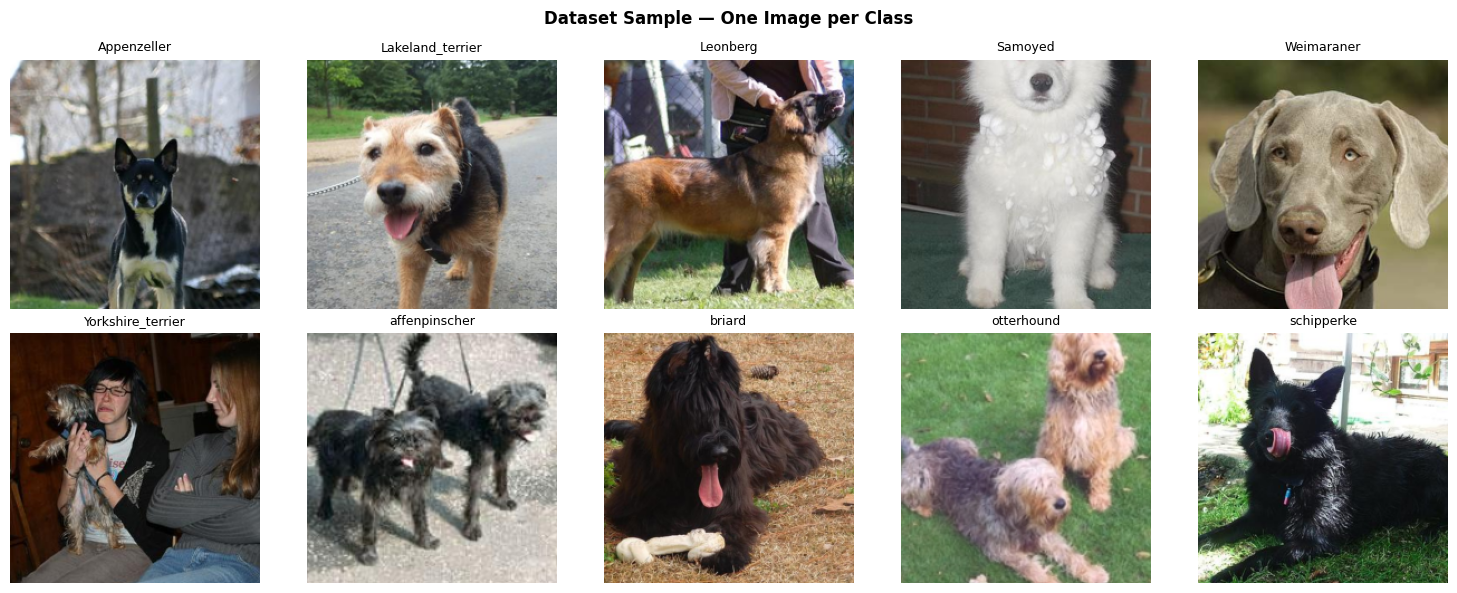

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
preview   = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
shown     = {}
for path, label in base_dataset.imgs:
    if label not in shown:
        shown[label] = path
    if len(shown) == NUM_CLASSES:
        break
for label in range(NUM_CLASSES):
    ax = axes.flatten()[label]
    ax.imshow(preview(Image.open(shown[label]).convert("RGB")))
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")
plt.suptitle("Dataset Sample — One Image per Class", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_dataset_samples.png", dpi=150)
plt.show()

In [5]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class TransformDataset(Dataset):
    """Wraps a Subset (returning PIL Images) and applies a transform on the fly."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label
    def __len__(self):
        return len(self.subset)

train_ds = TransformDataset(Subset(base_dataset, train_idx), train_transform)
val_ds   = TransformDataset(Subset(base_dataset, val_idx),   val_transform)
test_ds  = TransformDataset(Subset(base_dataset, test_idx),  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1190 | Val: 251 | Test: 266


In [6]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    metric = MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        metric.update(outputs, labels)
    return running_loss / len(loader), metric.compute().item()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    metric = MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item()
        metric.update(outputs, labels)
    return running_loss / len(loader), metric.compute().item()

## Experiment 1 — Baseline ResNet18

ResNet18 pretrained on ImageNet (ILSVRC 2012). The final fully-connected layer
is replaced with `Linear(512, 10)` for our 10 dog breeds. All other layers retain
their pretrained weights and are fine-tuned end-to-end.

In [7]:
def build_resnet18(num_classes):
    model    = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model1     = build_resnet18(NUM_CLASSES).to(DEVICE)
total1     = sum(p.numel() for p in model1.parameters())
trainable1 = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f"Total params:     {total1:,}")
print(f"Trainable params: {trainable1:,}")
print(model1)

Total params:     11,181,642
Trainable params: 11,181,642
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [8]:
optimizer1 = torch.optim.Adam(model1.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=EPOCHS, eta_min=1e-6)

best_val_acc     = 0.0
patience_counter = 0
history1         = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    current_lr                = optimizer1.param_groups[0]["lr"]
    train_loss, train_acc     = train_one_epoch(model1, train_loader, optimizer1)
    val_loss, val_acc         = evaluate(model1, val_loader)
    scheduler1.step()

    history1["train_loss"].append(train_loss)
    history1["val_loss"].append(val_loss)
    history1["train_acc"].append(train_acc)
    history1["val_acc"].append(val_acc)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"acc={train_acc:.4f}/{val_acc:.4f}  "
          f"lr={current_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save(model1.state_dict(), EXP1_DIR / "best.pth")
        print(f"  → Best saved (val_acc={best_val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break

Epoch   1/150  loss=1.7884/1.0304  acc=0.4391/0.8190  lr=1.00e-04
  → Best saved (val_acc=0.8190)
Epoch   2/150  loss=0.7932/0.4951  acc=0.8638/0.8850  lr=1.00e-04
  → Best saved (val_acc=0.8850)
Epoch   3/150  loss=0.4223/0.2980  acc=0.9304/0.9022  lr=1.00e-04
  → Best saved (val_acc=0.9022)
Epoch   4/150  loss=0.2581/0.2240  acc=0.9529/0.9200  lr=9.99e-05
  → Best saved (val_acc=0.9200)
Epoch   5/150  loss=0.1778/0.2096  acc=0.9679/0.9384  lr=9.98e-05
  → Best saved (val_acc=0.9384)
Epoch   6/150  loss=0.1340/0.2015  acc=0.9765/0.9382  lr=9.97e-05
Epoch   7/150  loss=0.1059/0.1917  acc=0.9790/0.9306  lr=9.96e-05
Epoch   8/150  loss=0.0817/0.1813  acc=0.9885/0.9414  lr=9.95e-05
  → Best saved (val_acc=0.9414)
Epoch   9/150  loss=0.0551/0.1804  acc=0.9972/0.9332  lr=9.93e-05
Epoch  10/150  loss=0.0515/0.1824  acc=0.9946/0.9364  lr=9.91e-05
Epoch  11/150  loss=0.0446/0.1758  acc=0.9965/0.9399  lr=9.89e-05
Epoch  12/150  loss=0.0358/0.1703  acc=1.0000/0.9399  lr=9.87e-05
Epoch  13/150  l

In [9]:
model1.load_state_dict(torch.load(EXP1_DIR / "best.pth", map_location=DEVICE, weights_only=True))
_, test_acc1 = evaluate(model1, test_loader)
print(f"=== Exp 1 (ResNet18) TEST ACCURACY: {test_acc1:.4f} ===")

cm_metric1 = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)
model1.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        cm_metric1.update(model1(imgs.to(DEVICE)), lbls.to(DEVICE))
cm1            = cm_metric1.compute().cpu().numpy()
per_class_acc1 = cm1.diagonal() / cm1.sum(axis=1)
print("\nPer-class accuracy on test set:")
for name, acc in zip(CLASS_NAMES, per_class_acc1):
    print(f"  {name:<22}: {acc:.4f}")

=== Exp 1 (ResNet18) TEST ACCURACY: 0.9563 ===

Per-class accuracy on test set:
  Appenzeller           : 1.0000
  Lakeland_terrier      : 0.9677
  Leonberg              : 0.9688
  Samoyed               : 1.0000
  Weimaraner            : 1.0000
  Yorkshire_terrier     : 0.9615
  affenpinscher         : 0.9565
  briard                : 0.9167
  otterhound            : 0.7917
  schipperke            : 1.0000


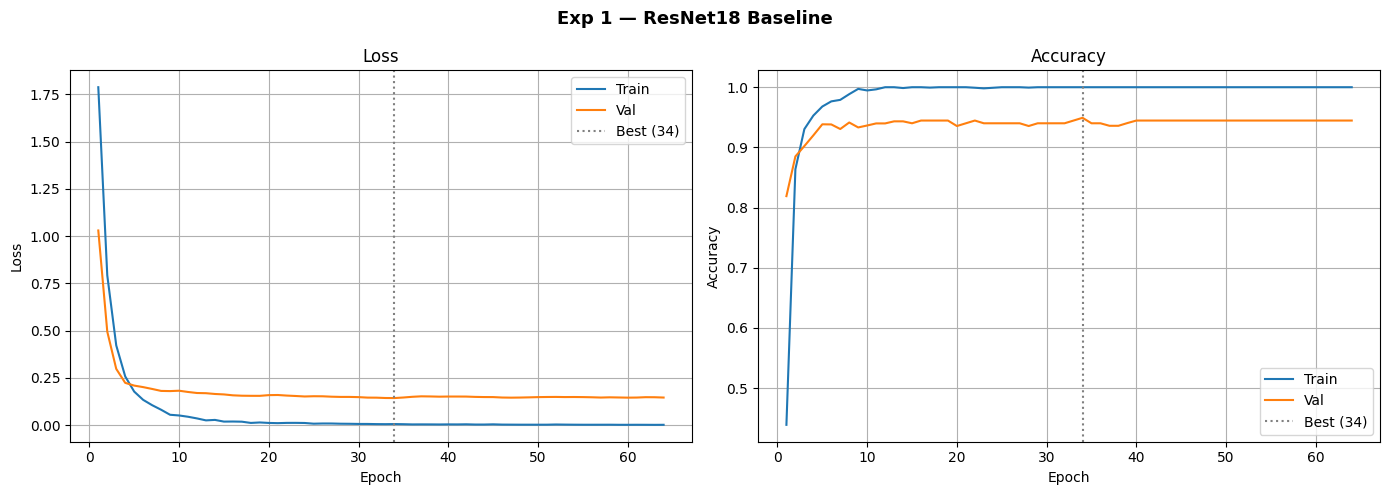

In [10]:
epochs_x    = range(1, len(history1["train_loss"]) + 1)
best_epoch1 = int(np.argmax(history1["val_acc"])) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_x, history1["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, history1["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch1, color="grey", linestyle=":", lw=1.5, label=f"Best ({best_epoch1})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss"); ax1.legend(); ax1.grid(True)
ax2.plot(epochs_x, history1["train_acc"], label="Train", color="tab:blue")
ax2.plot(epochs_x, history1["val_acc"],   label="Val",   color="tab:orange")
ax2.axvline(best_epoch1, color="grey", linestyle=":", lw=1.5, label=f"Best ({best_epoch1})")
ax2.set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy"); ax2.legend(); ax2.grid(True)
plt.suptitle("Exp 1 \u2014 ResNet18 Baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(EXP1_DIR / "training_curves.png", dpi=150)
plt.show()

## Experiment 2 — Modified ResNet18 (Shallow)

`layer4` (the deepest residual stage, 512 channels) is removed, leaving three residual
stages (64 → 128 → 256 channels). This reduces the total conv layers from 17 to 13
and the feature dimension entering the classifier from 512 to 256.

Pretrained ImageNet weights are reused for `conv1`, `bn1`, `layer1`, `layer2`, and `layer3`.
Only the final `Linear(256, 10)` head is randomly initialised.

In [11]:
class ResNet18Shallow(nn.Module):
    """
    ResNet18 with layer4 removed.
    Pretrained weights from conv1 through layer3 are reused; only fc is randomly initialised.
    Feature dimension at the classifier: 256 (vs 512 in the baseline).
    """
    def __init__(self, num_classes):
        super().__init__()
        base         = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.conv1   = base.conv1
        self.bn1     = base.bn1
        self.relu    = base.relu
        self.maxpool = base.maxpool
        self.layer1  = base.layer1   # 64 ch
        self.layer2  = base.layer2   # 128 ch
        self.layer3  = base.layer3   # 256 ch  (layer4 / 512 ch removed)
        self.avgpool = base.avgpool
        self.fc      = nn.Linear(256, num_classes)  # randomly initialised

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer3(self.layer2(self.layer1(x)))
        return self.fc(torch.flatten(self.avgpool(x), 1))

model2     = ResNet18Shallow(NUM_CLASSES).to(DEVICE)
total2     = sum(p.numel() for p in model2.parameters())
trainable2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"Total params:     {total2:,}")
print(f"Trainable params: {trainable2:,}")
print(model2)

Total params:     2,785,354
Trainable params: 2,785,354
ResNet18Shallow(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [12]:
optimizer2 = torch.optim.Adam(model2.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=EPOCHS, eta_min=1e-6)

best_val_acc     = 0.0
patience_counter = 0
history2         = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    current_lr                = optimizer2.param_groups[0]["lr"]
    train_loss, train_acc     = train_one_epoch(model2, train_loader, optimizer2)
    val_loss, val_acc         = evaluate(model2, val_loader)
    scheduler2.step()

    history2["train_loss"].append(train_loss)
    history2["val_loss"].append(val_loss)
    history2["train_acc"].append(train_acc)
    history2["val_acc"].append(val_acc)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={train_loss:.4f}/{val_loss:.4f}  "
          f"acc={train_acc:.4f}/{val_acc:.4f}  "
          f"lr={current_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save(model2.state_dict(), EXP2_DIR / "best.pth")
        print(f"  → Best saved (val_acc={best_val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping — no improvement for {PATIENCE} epochs.")
            break

Epoch   1/150  loss=2.2908/2.2682  acc=0.1605/0.2503  lr=1.00e-04
  → Best saved (val_acc=0.2503)
Epoch   2/150  loss=2.2576/2.2348  acc=0.3495/0.2826  lr=1.00e-04
  → Best saved (val_acc=0.2826)
Epoch   3/150  loss=2.2228/2.1943  acc=0.3883/0.3246  lr=1.00e-04
  → Best saved (val_acc=0.3246)
Epoch   4/150  loss=2.1804/2.1394  acc=0.4284/0.3731  lr=9.99e-05
  → Best saved (val_acc=0.3731)
Epoch   5/150  loss=2.1293/2.0598  acc=0.4387/0.4147  lr=9.98e-05
  → Best saved (val_acc=0.4147)
Epoch   6/150  loss=2.0670/1.9514  acc=0.4662/0.4386  lr=9.97e-05
  → Best saved (val_acc=0.4386)
Epoch   7/150  loss=2.0029/1.8300  acc=0.4994/0.4841  lr=9.96e-05
  → Best saved (val_acc=0.4841)
Epoch   8/150  loss=1.9249/1.7091  acc=0.5298/0.5030  lr=9.95e-05
  → Best saved (val_acc=0.5030)
Epoch   9/150  loss=1.8578/1.5937  acc=0.5544/0.5037  lr=9.93e-05
  → Best saved (val_acc=0.5037)
Epoch  10/150  loss=1.7821/1.5039  acc=0.5975/0.5452  lr=9.91e-05
  → Best saved (val_acc=0.5452)
Epoch  11/150  loss=

In [13]:
model2.load_state_dict(torch.load(EXP2_DIR / "best.pth", map_location=DEVICE, weights_only=True))
_, test_acc2 = evaluate(model2, test_loader)
print(f"=== Exp 2 (ResNet18 Shallow) TEST ACCURACY: {test_acc2:.4f} ===")

cm_metric2 = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)
model2.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        cm_metric2.update(model2(imgs.to(DEVICE)), lbls.to(DEVICE))
cm2            = cm_metric2.compute().cpu().numpy()
per_class_acc2 = cm2.diagonal() / cm2.sum(axis=1)
print("\nPer-class accuracy on test set:")
for name, acc in zip(CLASS_NAMES, per_class_acc2):
    print(f"  {name:<22}: {acc:.4f}")

=== Exp 2 (ResNet18 Shallow) TEST ACCURACY: 0.8985 ===

Per-class accuracy on test set:
  Appenzeller           : 1.0000
  Lakeland_terrier      : 0.8387
  Leonberg              : 0.9688
  Samoyed               : 0.9706
  Weimaraner            : 0.9583
  Yorkshire_terrier     : 0.8846
  affenpinscher         : 0.7391
  briard                : 0.8333
  otterhound            : 0.7917
  schipperke            : 1.0000


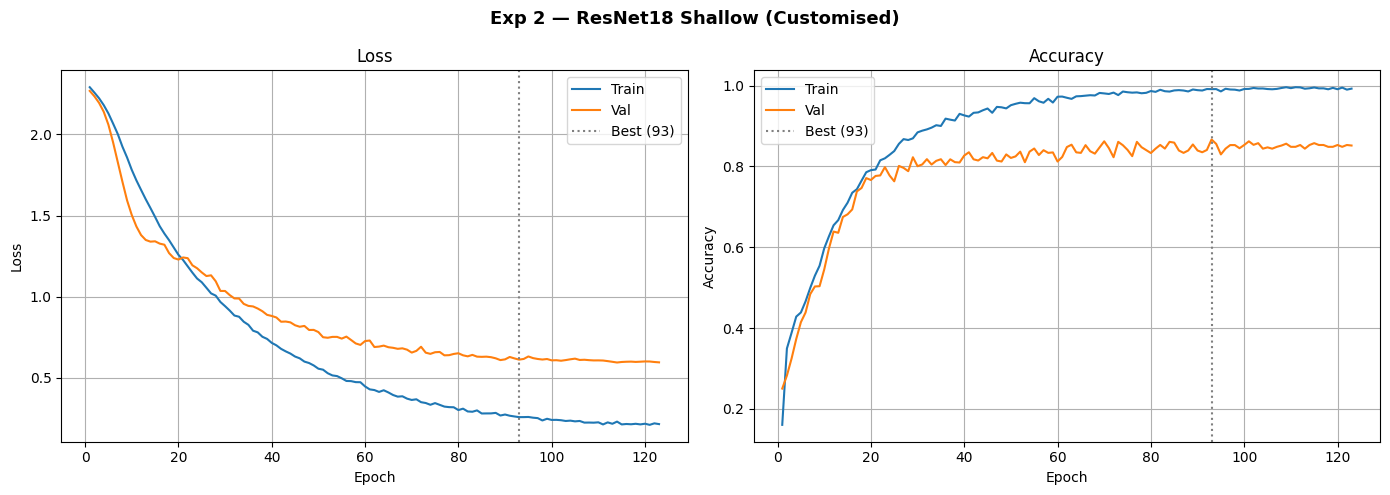

In [14]:
epochs_x    = range(1, len(history2["train_loss"]) + 1)
best_epoch2 = int(np.argmax(history2["val_acc"])) + 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_x, history2["train_loss"], label="Train", color="tab:blue")
ax1.plot(epochs_x, history2["val_loss"],   label="Val",   color="tab:orange")
ax1.axvline(best_epoch2, color="grey", linestyle=":", lw=1.5, label=f"Best ({best_epoch2})")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss"); ax1.legend(); ax1.grid(True)
ax2.plot(epochs_x, history2["train_acc"], label="Train", color="tab:blue")
ax2.plot(epochs_x, history2["val_acc"],   label="Val",   color="tab:orange")
ax2.axvline(best_epoch2, color="grey", linestyle=":", lw=1.5, label=f"Best ({best_epoch2})")
ax2.set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy"); ax2.legend(); ax2.grid(True)
plt.suptitle("Exp 2 \u2014 ResNet18 Shallow (Customised)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(EXP2_DIR / "training_curves.png", dpi=150)
plt.show()

## Comparison — Exp 1 vs Exp 2

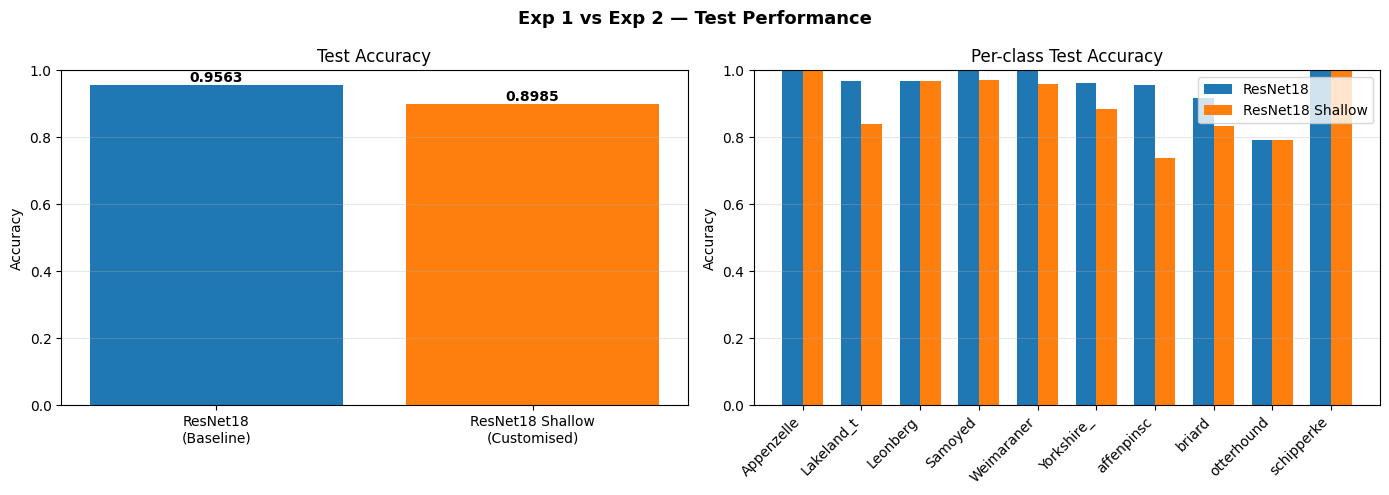


Parameter comparison:
  ResNet18 (Exp 1):         11,181,642 params
  ResNet18 Shallow (Exp 2):  2,785,354 params
  Reduction:                75.1%


In [15]:
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_labels = ["ResNet18\n(Baseline)", "ResNet18 Shallow\n(Customised)"]
accs         = [test_acc1, test_acc2]
bars = axes[0].bar(range(2), accs, color=["tab:blue", "tab:orange"])
axes[0].set_xticks(range(2))
axes[0].set_xticklabels(model_labels)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test Accuracy")
axes[0].set_ylim(0, 1)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, acc + 0.01,
                 f"{acc:.4f}", ha="center", fontweight="bold")
axes[0].grid(True, axis="y", alpha=0.3)

x = np.arange(NUM_CLASSES)
axes[1].bar(x - width / 2, per_class_acc1, width, label="ResNet18",         color="tab:blue")
axes[1].bar(x + width / 2, per_class_acc2, width, label="ResNet18 Shallow", color="tab:orange")
axes[1].set_xticks(x)
axes[1].set_xticklabels([c[:10] for c in CLASS_NAMES], rotation=45, ha="right")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Per-class Test Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Exp 1 vs Exp 2 \u2014 Test Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_comparison.png", dpi=150)
plt.show()

print(f"\nParameter comparison:")
print(f"  ResNet18 (Exp 1):         {total1:>10,} params")
print(f"  ResNet18 Shallow (Exp 2): {total2:>10,} params")
print(f"  Reduction:                {(1 - total2 / total1) * 100:.1f}%")

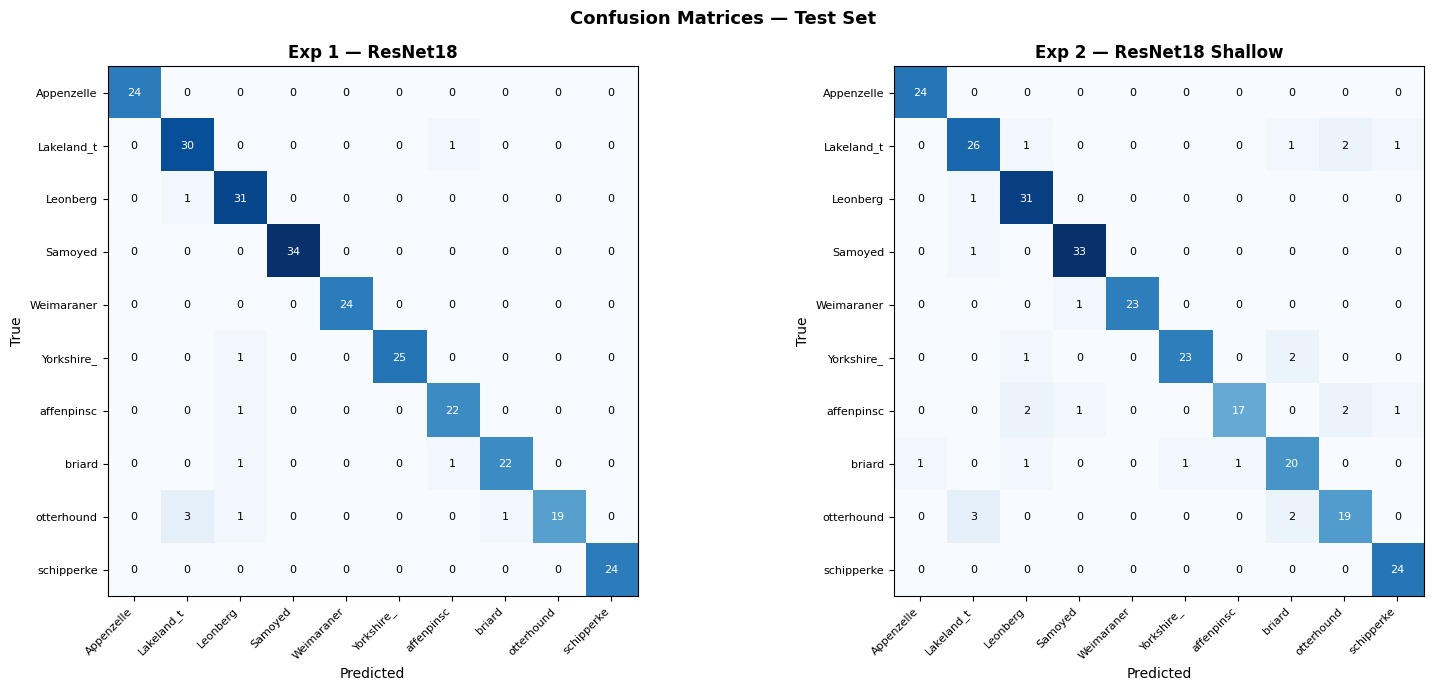

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
short_names = [c[:10] for c in CLASS_NAMES]
for ax, cm, title in [
    (ax1, cm1, "Exp 1 \u2014 ResNet18"),
    (ax2, cm2, "Exp 2 \u2014 ResNet18 Shallow")
]:
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = cm.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=8, color="white" if cm[i, j] > thresh else "black")
plt.suptitle("Confusion Matrices \u2014 Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_confusion_matrices.png", dpi=150)
plt.show()

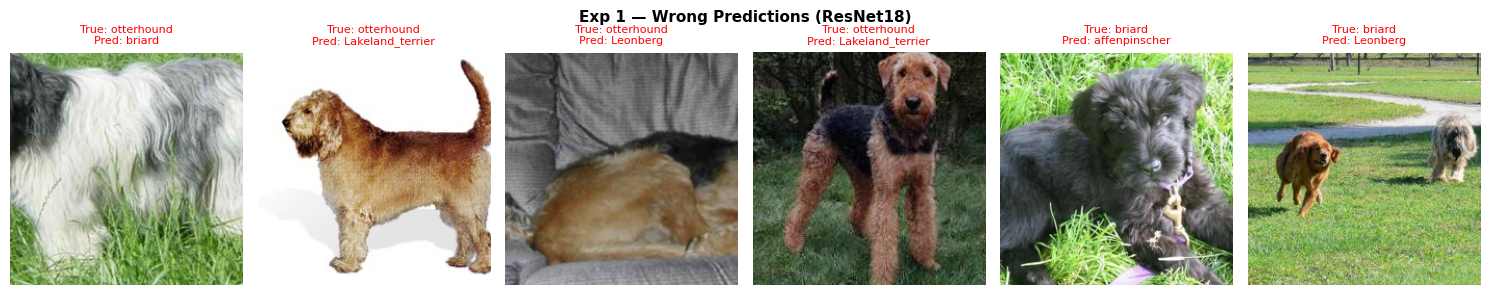

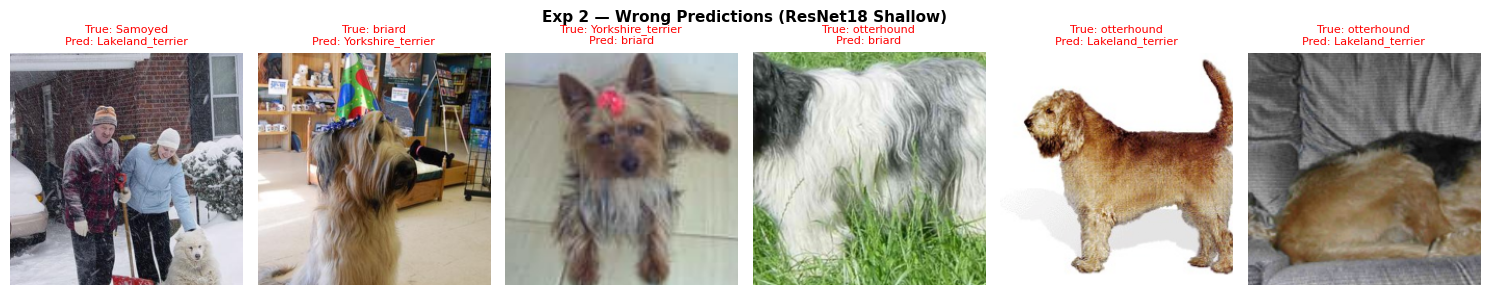

In [17]:
@torch.no_grad()
def get_wrong_predictions(model, dataset, n=6, seed=STUDENT_ID):
    model.eval()
    indices = list(range(len(dataset)))
    random.Random(seed).shuffle(indices)
    wrong = []
    for idx in indices:
        img_t, true_label = dataset[idx]
        pred_label = model(img_t.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
        if pred_label != true_label:
            wrong.append((img_t, true_label, pred_label))
        if len(wrong) >= n:
            break
    return wrong

def show_wrong_predictions(model, title, save_path, n=6):
    wrong = get_wrong_predictions(model, test_ds, n=n)
    if not wrong:
        print(f"{title}: no wrong predictions found.")
        return
    mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    fig, axes = plt.subplots(1, len(wrong), figsize=(len(wrong) * 2.5, 3))
    if len(wrong) == 1:
        axes = [axes]
    for ax, (img_t, true, pred) in zip(axes, wrong):
        img = (img_t * std_t + mean_t).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)
        ax.set_title(f"True: {CLASS_NAMES[true]}\nPred: {CLASS_NAMES[pred]}",
                     fontsize=8, color="red")
        ax.axis("off")
    plt.suptitle(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

show_wrong_predictions(model1, "Exp 1 \u2014 Wrong Predictions (ResNet18)",
                       EXP1_DIR / "wrong_predictions.png")
show_wrong_predictions(model2, "Exp 2 \u2014 Wrong Predictions (ResNet18 Shallow)",
                       EXP2_DIR / "wrong_predictions.png")